In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import sqlalchemy as sql
import urllib
import re

**Connecting Database**

In [77]:
# Connection parameters
server = 'DESKTOP-3QCNPJH\SQLEXPRESS01'
database = 'CohortAnalysis'

params = urllib.parse.quote_plus(
    f'DRIVER=ODBC Driver 17 for SQL Server;'
    f'SERVER={server};'
    f'DATABASE={database};'
    'Trusted_Connection=yes;'
)

engine = sql.create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

<>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_30548\1885591938.py:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  server = 'DESKTOP-3QCNPJH\SQLEXPRESS01'


**Data Loading**

In [78]:
df = pd.read_sql("select * from online_retail", engine)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,571408,23313,VINTAGE CHRISTMAS BUNTING,1,2011-10-17 12:22:00,4.95,15012.0,United Kingdom
1,571408,21466,RED FLOWER CROCHET FOOD COVER,1,2011-10-17 12:22:00,3.75,15012.0,United Kingdom
2,571408,22776,SWEETHEART 3 TIER CAKE STAND,1,2011-10-17 12:22:00,9.95,15012.0,United Kingdom
3,571408,23168,CLASSIC CAFE SUGAR DISPENSER,1,2011-10-17 12:22:00,1.25,15012.0,United Kingdom
4,571408,23339,EGG FRYING PAN BLUE,1,2011-10-17 12:22:00,2.08,15012.0,United Kingdom


**Check Missing Value**

In [80]:
null_df = pd.DataFrame(columns = ['null_count'])
for col in df.columns :
    null_check = pd.read_sql(
    f'''
                             select count(*) 
                             from online_retail 
                             where {col} is null
    ''', engine)
    
    null_df.loc[col, 'null_count'] = null_check.values[0][0]

In [81]:
null_df

,null_count
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,2
CustomerID,135080
Country,0


**Data Cleaning**
- Menghapus Customer ID Null  
  Menghilangkan data tanpa identitas pelanggan agar setiap transaksi dapat ditelusuri dan dikelompokkan ke dalam cohort dengan benar.
- Memfilter Quantity > 0  
    Menghapus transaksi retur atau pembatalan sehingga hanya aktivitas pembelian yang dihitung.

- Memfilter Unit Price > 0  
    Menghapus data tidak valid atau bukan transaksi penjualan yang sebenarnya.

Kesimpulan:  
Pembersihan data bertujuan memastikan hanya transaksi valid dan pelanggan teridentifikasi yang digunakan, sehingga analisis cohort retention menjadi akurat.

In [ ]:
all_columns = ",".join(df.columns)

query1 = f"""
            IF NOT EXISTS (
                SELECT * 
                FROM sysobjects 
                WHERE 
                    name = 'cleaned_data'
                    AND
                    xtype = 'U'
            )
            BEGIN
                with 
                    cleaned_customer_id as (
                        select * 
                        from online_retail
                        where CustomerID IS NOT NULL
                    ),
                    cleaned_quantity_unit_price as (
                        select * 
                        from cleaned_customer_id
                        where Quantity > 0 and UnitPrice > 0

                    ),
                    duplicated_check as (
                        select 
                            cqu.*,
                            ROW_NUMBER() OVER (PARTITION BY {all_columns} ORDER BY InvoiceDate) as row_num
                        from cleaned_quantity_unit_price cqu
                    ),
                    cleaned_from_duplicated as (
                        select * 
                        from duplicated_check
                        where row_num = 1
                    )

                select {all_columns} into cleaned_data from cleaned_from_duplicated
            END

"""

# DDL harus pake ini karena outputnya hanya proses
with engine.connect() as conn :
    conn.execute(sql.text(query1))
    conn.commit()

**Create Cohort Table**

In [ ]:
count_query = lambda i : f"COUNT(DISTINCT CASE WHEN UserIndexDate = {i} THEN CustomerID END) as [{i}],"
subquery = (" ".join(count_query(i) for i in range(12)))[:-1]

query2 = f"""
        with 
            user_first_invoice_date as (
                select 
                    cd.*,
                    DATEFROMPARTS(
                        YEAR(MIN(InvoiceDate) OVER (PARTITION BY CustomerID)), 
                        MONTH(MIN(InvoiceDate) OVER (PARTITION BY CustomerID)), 
                        1
                    ) as user_first_invoice_date 
                from cleaned_data cd
            ),
            user_index_date as (
                select 
                    ufi.*,
                    DATEDIFF(MONTH, user_first_invoice_date, InvoiceDate) as UserIndexDate
                from user_first_invoice_date ufi
            ),
            cohort_table as (
                select 
                    user_first_invoice_date,
                    {subquery}
                from user_index_date
                group by user_first_invoice_date
                
            )
            
        select * from cohort_table
        order by user_first_invoice_date
"""

# Execute Query
cohort_table = pd.read_sql(query2, engine)
cohort_table = cohort_table.set_index('user_first_invoice_date')
cohort_table.index = pd.to_datetime(cohort_table.index).strftime('%m-%Y')
cohort_table

**Create Retention Table**

In [85]:
retention_table = np.round(cohort_table.divide(cohort_table.loc[:, '0'].values, axis = 0) * 100, 2)
retention_table

,0,1,2,3,4,5,6,7,8,9,10,11
user_first_invoice_date,,,,,,,,,,,,
12-2010,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28
01-2011,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75
02-2011,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,6.84,0.00
03-2011,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,8.63,0.00,0.00
04-2011,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,7.33,0.00,0.00,0.00
05-2011,100.0,19.01,17.25,17.25,20.77,23.24,26.41,9.51,0.00,0.00,0.00,0.00
06-2011,100.0,17.36,15.70,26.45,23.14,33.47,9.50,0.00,0.00,0.00,0.00,0.00
07-2011,100.0,18.09,20.74,22.34,27.13,11.17,0.00,0.00,0.00,0.00,0.00,0.00
08-2011,100.0,20.71,24.85,24.26,12.43,0.00,0.00,0.00,0.00,0.00,0.00,0.00


**Data Visualization - Heatmap**

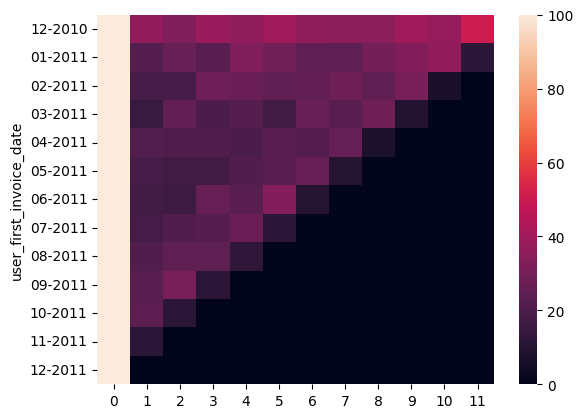

In [86]:
sns.heatmap(retention_table);

**Data Visualization - Cohort Breakdown Plot**

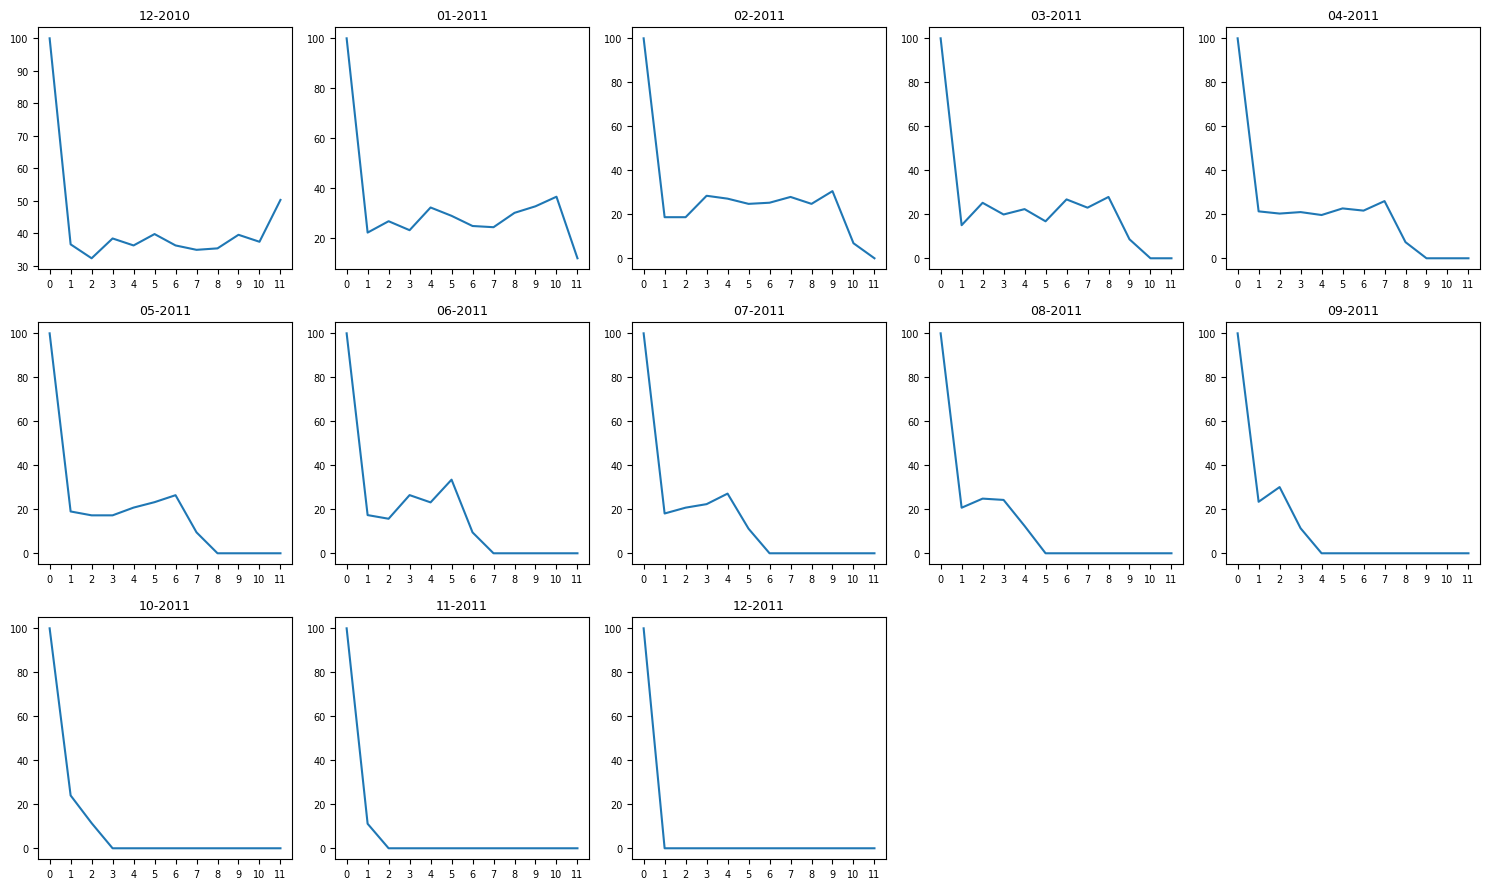

In [122]:
rows, cols = 3, 5  
fig = plt.figure(figsize = (15, 9))
gs  = GridSpec(rows, cols, figure = fig)

for i, cohort in enumerate(retention_table.index):
    r = i // cols
    c = i % cols
    
    ax = fig.add_subplot(gs[r, c])
    ax.plot(retention_table.columns, retention_table.loc[cohort].values)
    ax.set_title(f'{cohort}', fontsize=9)
    ax.tick_params(labelsize = 7)

plt.tight_layout()
plt.show()

**Insights**
- Retention  
  - Retention selalu turun seiring waktu  
  - Drop terbesar terjadi di awal 
    (bulan 1 → 2)  
  - Hanya sebagian kecil user yang 
   kembali

- Masalah
  - Ada periode dengan retention = 0
  - Indikasi masalah serius (user tidak 
    kembali sama sekali)
  - Perlu evaluasi di fase awal customer 
    journey

- Performa
  - Performa antar cohort berbeda
  - Ada cohort yang lebih loyal dari yang lain

- Bisnis
  - Kemungkinan pengaruh campaign/strategi
  - Perlu fokus ke early retention improvement
  - Optimasi pengalaman setelah pembelian 
    pertama